# Keyword Intent Validation — Raspberry Pi

Validates the **31-class command ("keyword intent") classifier** on the target
device and reports the four numbers that matter for an edge deployment:

| Metric | What it means |
|---|---|
| **Keyword intent accuracy** | top-1 / top-3 / top-5 accuracy, per-intent precision/recall/F1, confusion matrix |
| **False accept rate (FAR)** | fraction of non-command / background clips wrongly accepted as a command (not rejected as `UNKNOWN`); plus FRR and a threshold sweep |
| **Latency** | frontend / ONNX / end-to-end ms (mean, median, p95, p99), real-time factor, throughput, thread sweep |
| **Runtime** | sustained run: latency drift + CPU temperature (thermal throttling) |

It uses the **same production code path** as the app
(`commands.CommandClassifier` + `features.MetadataFrontend`), so the numbers are
what the device actually does.

### Data
* **Positives** — labeled command clips in `test_data/<CLASS>/*.wav`
  (or a `manifest.csv` with `path,label`).
* **Negatives** — non-command clips for FAR in `test_data/<negative-dir>/*.wav`
  where the directory is named `_negative`, `negatives`, `unknown`,
  `background`, `noise` or `noncommand`.
  If none are found, non-speech negatives (silence / noise / tones) are
  **synthesized** so FAR is still reported (as a smoke test).

Only `numpy`, `onnxruntime`, `soundfile` are required. `matplotlib`, `pandas`,
`psutil` are optional (plots / RAM / CSVs):

```bash
pip install matplotlib pandas psutil
```

In [1]:
# ============================================================
# Configuration -- edit, then run top-to-bottom
# ============================================================
TEST_DATA_DIR       = None     # dir with <CLASS>/*.wav or manifest.csv (None = auto)
NEG_DIR             = None     # explicit negatives dir (None = auto-discover)
SYNTHETIC_NEGATIVES = True     # synth non-speech negatives if no negative audio found
MANIFEST_CSV        = None     # optional manifest (columns: path,label)
N_WARMUP            = 10
N_RUNS              = 100
THREAD_SWEEP        = [1, 2, 4]
SUSTAINED_SECONDS   = 30
UNKNOWN_THRESHOLD   = None     # None = use command_metadata.json value (0.163)
SAMPLE_RATE         = 16000
RESULTS_DIR         = None     # None = ./results

import csv, json, os, platform, subprocess, sys, time
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np

try:
    import psutil
    HAVE_PSUTIL = True
except Exception:
    HAVE_PSUTIL = False
try:
    import matplotlib
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except Exception:
    HAVE_MPL = False
try:
    import pandas as pd
    HAVE_PANDAS = True
except Exception:
    HAVE_PANDAS = False

HERE = Path.cwd()
RESULTS_DIR = Path(RESULTS_DIR) if RESULTS_DIR else (HERE / "results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

NEG_DIR_NAMES = {"_negative", "negatives", "negative", "unknown",
                 "background", "noise", "noncommand", "non_command"}


def find_app_dir(start: Path):
    marker = ("models", "command_classifier", "command_metadata.json")
    for base in [start, *start.parents]:
        if (base / "commands.py").exists() and (base / Path(*marker)).exists():
            return base
    for base in [start, *start.parents]:
        for p in base.glob("*/commands.py"):
            if (p.parent / Path(*marker)).exists():
                return p.parent
    return None


APP_DIR = find_app_dir(HERE)
assert APP_DIR is not None, "Could not locate the app folder (commands.py + model)."
sys.path.insert(0, str(APP_DIR))
# ---- Choose the classifier to validate: "MEX2-31class" or "MEX2-trained" ----
CLASSIFIER = "MEX2-31class"
import yaml
_cfg = yaml.safe_load(open(APP_DIR / "config.yaml"))
_reg = ((_cfg.get("command", {}) or {}).get("models", {}) or {}) or {"default": "models/command_classifier"}
_k = next((k for k in _reg if CLASSIFIER.lower() in (k.lower(), Path(_reg[k]).name.lower())), None)
assert _k, f"Unknown CLASSIFIER {CLASSIFIER!r}; options: {list(_reg)}"
MODEL_DIR = APP_DIR / _reg[_k]
ONNX_PATH = next((MODEL_DIR / f for f in ("best_model.onnx", "command_classifier.onnx")
                  if (MODEL_DIR / f).exists()), MODEL_DIR / "best_model.onnx")
print("classifier:", _k, "->", MODEL_DIR)
print("app dir   :", APP_DIR, "| results:", RESULTS_DIR)
print("optional  : matplotlib=%s pandas=%s psutil=%s" % (HAVE_MPL, HAVE_PANDAS, HAVE_PSUTIL))

classifier: MEX2-31class -> /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app/models/command_classifier
app dir   : /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app | results: /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app/rpi_validation/results
optional  : matplotlib=True pandas=False psutil=True


## 1. Runtime environment

In [2]:
def _read_first(paths):
    for p in paths:
        try:
            return Path(p).read_bytes().decode(errors="ignore").strip("\x00").strip()
        except Exception:
            pass
    return None


def rpi_model():
    return _read_first(["/proc/device-tree/model", "/sys/firmware/devicetree/base/model"])


def cpu_temp_c():
    v = _read_first(["/sys/class/thermal/thermal_zone0/temp"])
    if v and v.strip().isdigit():
        return int(v.strip()) / 1000.0
    try:
        out = subprocess.check_output(["vcgencmd", "measure_temp"],
                                      stderr=subprocess.DEVNULL).decode()
        return float(out.strip().split("=")[1].split("'")[0])
    except Exception:
        return None


def mem_total_mb():
    if HAVE_PSUTIL:
        return psutil.virtual_memory().total / 1e6
    v = _read_first(["/proc/meminfo"])
    if v:
        for line in v.splitlines():
            if line.startswith("MemTotal:"):
                return int(line.split()[1]) / 1024.0
    return None


import onnxruntime as ort

ENV = {"python": sys.version.split()[0], "platform": platform.platform(),
       "machine": platform.machine(), "cpu_count": os.cpu_count(),
       "rpi_model": rpi_model(), "cpu_temp_c": cpu_temp_c(),
       "ram_mb": (round(mem_total_mb(), 1) if mem_total_mb() else None),
       "onnxruntime": ort.__version__, "providers": ort.get_available_providers(),
       "numpy": np.__version__}
for k, v in ENV.items():
    print(f"{k:14s}: {v}")

python        : 3.13.5
platform      : Linux-6.18.50+rpt-rpi-2712-aarch64-with-glibc2.41
machine       : aarch64
cpu_count     : 4
rpi_model     : Raspberry Pi 5 Model B Rev 1.1
cpu_temp_c    : 59.5
ram_mb        : 8449.8
onnxruntime   : 1.21
providers     : ['DnnlExecutionProvider', 'XnnpackExecutionProvider', 'CPUExecutionProvider']
numpy         : 2.2.4


## 2. Model & frontend

In [3]:
# ---- 2. Model + frontend (works with BOTH classifier formats) ----
CMD_META = MODEL_DIR / "command_metadata.json"
CMD_LABELS = MODEL_DIR / "labels.json"

from commands import CommandClassifier
from features import read_wav_mono_16k

if CMD_META.exists():                         # bundled / metadata format
    META = json.load(open(CMD_META))
    CLASSES = [None] * len(META["class_to_idx"])
    for name, i in META["class_to_idx"].items():
        CLASSES[int(i)] = name
    _thr = float(META.get("unknown_threshold", 0.5))
else:                                         # trained / frontend.json format
    _lab = json.load(open(CMD_LABELS))
    CLASSES = [_lab["id_to_class"][str(i)] for i in range(len(_lab["id_to_class"]))]
    _thr = 0.5

THR = float(UNKNOWN_THRESHOLD) if UNKNOWN_THRESHOLD is not None else float(_thr)

t0 = time.perf_counter()
clf = CommandClassifier(MODEL_DIR, intents=CLASSES, unknown_threshold=THR)
LOAD_MS = (time.perf_counter() - t0) * 1e3
assert clf.real, "classifier ONNX not found / not loaded"

CLASSES = list(clf.intents)
NUM_CLASSES = len(CLASSES)
THR = float(clf.unknown_threshold)
UNKNOWN_THRESHOLD = THR

_raw_fe = clf.frontend
SR = int(getattr(_raw_fe, "sr", getattr(_raw_fe, "sample_rate", SAMPLE_RATE)))
WIN = int(getattr(_raw_fe, "window_samples", None) or getattr(_raw_fe, "n_samples", None)
          or int(SR * getattr(_raw_fe, "clip_duration", 2.0)))
CLIP_S = WIN / SR


def fe(w):                      # always (1, 1, n_mels, T) for a direct sess.run()
    y = np.asarray(_raw_fe(w), dtype=np.float32)
    return y[None, None] if y.ndim == 2 else y

print(f"model load   : {LOAD_MS:.1f} ms")
print(f"model dir    : {MODEL_DIR}")
print(f"onnx         : {clf.onnx_name}  frontend={clf.frontend_kind}")
print(f"classes      : {NUM_CLASSES}")
print(f"UNKNOWN thr  : {THR}")
print(f"input/output : {clf.sess.get_inputs()[0].shape} -> {clf.sess.get_outputs()[0].shape}")
print(f"window       : {WIN} samples ({CLIP_S*1000:.1f} ms @ {SR} Hz)")


def load_wav(p):
    return read_wav_mono_16k(p, SAMPLE_RATE)

model load   : 90.2 ms
model dir    : /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app/models/command_classifier
onnx         : command_classifier.onnx  frontend=metadata
classes      : 31
UNKNOWN thr  : 0.163
input/output : [1, 1, 64, 150] -> [1, 31]
window       : 24352 samples (1522.0 ms @ 16000 Hz)


Schema error: Trying to register schema with name Abs (domain:  version: 1) from file ./onnx/defs/math/old.cc line 2729, but it is already registered from file ./onnx/defs/math/old.cc line 2729

Schema error: Trying to register schema with name Add (domain:  version: 1) from file ./onnx/defs/math/old.cc line 2627, but it is already registered from file ./onnx/defs/math/old.cc line 2627

Schema error: Trying to register schema with name And (domain:  version: 1) from file ./onnx/defs/logical/old.cc line 132, but it is already registered from file ./onnx/defs/logical/old.cc line 132

Schema error: Trying to register schema with name ArgMax (domain:  version: 1) from file ./onnx/defs/reduction/old.cc line 357, but it is already registered from file ./onnx/defs/reduction/old.cc line 357

Schema error: Trying to register schema with name ArgMin (domain:  version: 1) from file ./onnx/defs/reduction/old.cc line 359, but it is already registered from file ./onnx/defs/reduction/old.cc line 359


ile ./onnx/defs/math/old.cc line 2217, but it is already registered from file ./onnx/defs/math/old.cc line 2217

Schema error: Trying to register schema with name Dropout (domain:  version: 12) from file ./onnx/defs/nn/old.cc line 1560, but it is already registered from file ./onnx/defs/nn/old.cc line 1560

Schema error: Trying to register schema with name Constant (domain:  version: 12) from file ./onnx/defs/generator/old.cc line 507, but it is already registered from file ./onnx/defs/generator/old.cc line 507

Schema error: Trying to register schema with name Celu (domain:  version: 12) from file ./onnx/defs/math/defs.cc line 523, but it is already registered from file ./onnx/defs/math/defs.cc line 523

Schema error: Trying to register schema with name Max (domain:  version: 12) from file ./onnx/defs/math/old.cc line 1563, but it is already registered from file ./onnx/defs/math/old.cc line 1563

Schema error: Trying to register schema with name Min (domain:  version: 12) from file ./

## 3. Data discovery (positives + negatives)

In [4]:

import re

NEG_DIR_NAMES = {"_negative", "negatives", "negative", "unknown", "background",
                 "noise", "noncommand", "non_command", "out_of_scope", "outofscope", "oos"}

# (command, slot_value) -> model class, for the slot intents
SLOT_MAP = {
    ("ALARM", "6:00 AM"): "ALARM_6_00AM",
    ("ALARM", "8:00 AM"): "ALARM_8_00AM",
    ("ALARM", "9:00 PM"): "ALARM_9_00PM",
    ("BRIGHTNESS", "20 percent"): "BRIGHTNESS_20",
    ("BRIGHTNESS", "60 percent"): "BRIGHTNESS_60",
    ("BRIGHTNESS", "100 percent"): "BRIGHTNESS_100",
    ("COLOR", "Red"): "COLOR_RED",
    ("COLOR", "Green"): "COLOR_GREEN",
    ("COLOR", "Blue"): "COLOR_BLUE",
    ("COLOR", "Yellow"): "COLOR_YELLOW",
    ("CREATE_REMINDER", "Drink water"): "CREATE_REMINDER_DRINK_WATER",
    ("CREATE_REMINDER", "Exercise"): "CREATE_REMINDER_EXERCISE",
    ("CREATE_REMINDER", "Study"): "CREATE_REMINDER_STUDY",
    ("TEMPERATURE", "18 degrees"): "TEMPERATURE_18",
    ("TEMPERATURE", "22 degrees"): "TEMPERATURE_22",
    ("TEMPERATURE", "26 degrees"): "TEMPERATURE_26",
    ("TIMER", "10 seconds"): "TIMER_10s",
    ("TIMER", "30 seconds"): "TIMER_30s",
    ("TIMER", "1 minute"): "TIMER_1m",
}


def _norm(x):
    return re.sub(r"[^a-z0-9]", "", str(x or "").lower())


def resolve_label(command, slot_value=""):
    """Map a manifest (command[, slot_value]) to one of the 31 model classes."""
    cmd = str(command or "").strip()
    slot = str(slot_value or "").strip()
    if cmd in CLASSES:
        return cmd
    cands = []
    if (cmd, slot) in SLOT_MAP:
        cands.append(SLOT_MAP[(cmd, slot)])
    for (c, s), cls in SLOT_MAP.items():                 # tolerant of case/format
        if c == cmd and _norm(s) == _norm(slot):
            cands.append(cls)
    cands += [f"{cmd}_{slot}".replace(" ", "_").upper(), f"{cmd}{slot}".upper()]
    nums = re.findall(r"\d+", slot)
    if nums:
        cands.append(f"{cmd}_{nums[0]}")
    cands.append(cmd.upper())
    for c in cands:
        if c in CLASSES:
            return c
    for c in cands:                                       # normalized match
        for cls in CLASSES:
            if _norm(cls) == _norm(c):
                return cls
    return None


def _pick(row, *names):
    for n in names:
        for k in row:
            if k.lower() == n:
                return k
    return None


def read_manifest(m):
    """Manifest (any schema) -> (positives[(path,class)], negatives[path], unresolved)."""
    with open(m, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    pos, neg, bad = [], [], []
    if not rows:
        return pos, neg, bad
    fk = _pick(rows[0], "file", "path", "wav", "filename")
    ck = _pick(rows[0], "command", "label", "class", "intent")
    sk = _pick(rows[0], "slot_value", "slot", "value")
    ok = _pick(rows[0], "out_of_scope", "outofscope", "oos", "is_negative", "negative")
    for r in rows:
        p = (r.get(fk) or "").strip() if fk else ""
        if not p:
            continue
        pp = Path(p)
        if not pp.is_absolute():
            pp = m.parent / pp
        if not pp.exists():                              # e.g. files under an audio/ subdir
            alt = m.parent / "audio" / Path(p).name
            if alt.exists():
                pp = alt
        cmd = (r.get(ck) or "").strip() if ck else ""
        slot = (r.get(sk) or "").strip() if sk else ""
        is_neg = (str(r.get(ok, "")).strip().lower() in ("1", "true", "yes") if ok else False) \
            or _norm(cmd) in {_norm(x) for x in NEG_DIR_NAMES}
        if is_neg:
            neg.append(pp)
            continue
        cls = resolve_label(cmd, slot)
        if cls:
            pos.append((pp, cls))
        else:
            bad.append((cmd, slot))
    return pos, neg, bad


def _roots(explicit):
    r = []
    if explicit:
        r.append(Path(explicit))
    r += [HERE / "test_data", APP_DIR / "data" / "command" / "test",
          APP_DIR / "data" / "command", APP_DIR / "test_data",
          APP_DIR / "data", APP_DIR.parent / "data" / "command" / "test"]
    return [x for x in r if x and x.exists()]


def _find_manifests(roots, explicit=None):
    ms = [Path(explicit)] if explicit else []
    for r in roots:
        ms += sorted(r.glob("*.csv")) + sorted(r.glob("*/manifest*.csv")) + sorted(r.glob("*/*.csv"))
    seen, out = set(), []
    for m in ms:
        if m.exists() and str(m.resolve()) not in seen:
            seen.add(str(m.resolve()))
            out.append(m)
    return out


# ---- discover positives + negatives (holdout manifest first) ----
POS, NEG_PATHS, BAD = [], [], []
POS_SRC, NEG_SRC = "none found", "none found"

for m in _find_manifests(_roots(TEST_DATA_DIR), MANIFEST_CSV):
    p, n, b = read_manifest(m)
    if p or n:
        POS, NEG_PATHS, BAD = p, n, b
        POS_SRC = f"manifest {m}"
        NEG_SRC = f"manifest {m}" if n else "none found"
        break

if not POS:                                     # fallback: folder-per-class
    for r in _roots(TEST_DATA_DIR):
        items = []
        for sub in sorted(d for d in r.iterdir()
                          if d.is_dir() and d.name.lower() not in NEG_DIR_NAMES):
            for w in sorted(sub.glob("*.wav")):
                items.append((w, sub.name))
        if items:
            POS, POS_SRC = items, f"folder-per-class {r}"
            break

if not NEG_PATHS:                               # fallback: negative folders
    for r in _roots(NEG_DIR):
        for sub in sorted(r.rglob("*")):
            if sub.is_dir() and sub.name.lower() in NEG_DIR_NAMES:
                wavs = sorted(sub.glob("*.wav"))
                if wavs:
                    NEG_PATHS, NEG_SRC = wavs, f"{sub}"
                    break
        if NEG_PATHS:
            break

print("positives :", len(POS), f"({POS_SRC})")
print("negatives :", len(NEG_PATHS), f"({NEG_SRC})")
if POS:
    print("per-intent:", dict(sorted(Counter(l for _, l in POS).items())))
if BAD:
    print("unresolved:", BAD[:8], f"(+{len(BAD)-8} more)" if len(BAD) > 8 else "")


positives : 186 (manifest /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app/rpi_validation/test_data/holdout/manifest.csv)
negatives : 10 (manifest /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app/rpi_validation/test_data/holdout/manifest.csv)
per-intent: {'ALARM_6_00AM': 6, 'ALARM_8_00AM': 6, 'ALARM_9_00PM': 6, 'BRIGHTNESS_100': 6, 'BRIGHTNESS_20': 6, 'BRIGHTNESS_60': 6, 'CALL': 6, 'COLOR_BLUE': 6, 'COLOR_GREEN': 6, 'COLOR_RED': 6, 'CREATE_REMINDER_DRINK_WATER': 6, 'CREATE_REMINDER_EXERCISE': 6, 'CREATE_REMINDER_STUDY': 6, 'LIGHT_OFF': 6, 'LIGHT_ON': 6, 'LIST_REMINDERS': 6, 'MESSAGE': 6, 'NEXT': 6, 'PAUSE': 6, 'PLAY_MUSIC': 6, 'STOP': 6, 'TEMPERATURE_18': 6, 'TEMPERATURE_22': 6, 'TEMPERATURE_26': 6, 'TIME': 6, 'TIMER_10s': 6, 'TIMER_1m': 6, 'TIMER_30s': 6, 'VOLUME_DOWN': 6, 'VOLUME_UP': 6, 'WEATHER': 6}


In [5]:
def synth_negatives(seed=0):
    """Non-speech negatives (silence / tones / noise) when no negative audio exists."""
    rng = np.random.default_rng(seed)
    t = np.arange(WIN) / SAMPLE_RATE
    clips = [np.zeros(WIN, np.float32),
             (0.1 * np.sin(2 * np.pi * 1000 * t)).astype(np.float32),
             (0.15 * np.sin(2 * np.pi * 220 * t) + 0.05 * rng.standard_normal(WIN)).astype(np.float32)]
    for level in (0.01, 0.03, 0.08):
        clips.append((level * rng.standard_normal(WIN)).astype(np.float32))
    return clips


NEG_WAVS, NEG_DESC = [], "none"
if NEG_PATHS:
    NEG_WAVS, NEG_DESC = [load_wav(p) for p in NEG_PATHS], NEG_SRC
elif SYNTHETIC_NEGATIVES:
    NEG_WAVS, NEG_DESC = synth_negatives(), "synthetic (silence/noise/tones)"
    print("No negative audio found -> using synthetic non-speech negatives (smoke test).")

POS_PROBS = POS_Y = None
if POS:
    POS_Y = np.array([CLASSES.index(l) for _, l in POS])
    POS_PROBS = np.vstack([clf.predict(load_wav(p)) for p, _ in POS])
NEG_PROBS = np.vstack([clf.predict(w) for w in NEG_WAVS]) if NEG_WAVS else None

print("positives scored:", 0 if POS_PROBS is None else len(POS_PROBS))
print("negatives scored:", 0 if NEG_PROBS is None else len(NEG_PROBS), f"({NEG_DESC})")

positives scored: 186
negatives scored: 10 (manifest /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app/rpi_validation/test_data/holdout/manifest.csv)


## 4. Keyword intent accuracy

Top-1 / top-3 / top-5 accuracy over the labeled command clips, plus per-intent
precision / recall / F1 and the confusion matrix.

In [6]:
ACC = None
if POS_PROBS is not None and len(POS_Y):
    ypred = POS_PROBS.argmax(1)
    conf = POS_PROBS.max(1)
    top1 = float((ypred == POS_Y).mean())

    def topk(k):
        order = np.argsort(-POS_PROBS, axis=1)[:, :k]
        return float(np.mean([POS_Y[i] in order[i] for i in range(len(POS_Y))]))

    cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)
    for t, p in zip(POS_Y, ypred):
        cm[t, p] += 1
    per = {}
    for i, name in enumerate(CLASSES):
        tp = int(cm[i, i]); fp = int(cm[:, i].sum()) - tp; fn = int(cm[i, :].sum()) - tp
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        per[name] = {"n": int(cm[i, :].sum()), "precision": prec, "recall": rec, "f1": f1}

    ACC = {"n": int(len(POS_Y)), "top1": top1, "top3": topk(3), "top5": topk(5),
           "macro_f1": float(np.mean([v["f1"] for v in per.values()]) if per else 0.0),
           "per_intent": per, "confusion": cm.tolist()}
    print(f"samples      : {ACC['n']}")
    print(f"top-1 acc    : {top1*100:.2f}%")
    print(f"top-3 / top-5: {ACC['top3']*100:.2f}% / {ACC['top5']*100:.2f}%")
    print(f"macro F1     : {ACC['macro_f1']*100:.2f}%")
    print(f"\n{'intent':30s} {'n':>4s} {'prec':>8s} {'rec':>8s} {'f1':>8s}")
    for name, m in per.items():
        if m["n"] or m["precision"] or m["recall"]:
            print(f"{name:30s} {m['n']:4d} {m['precision']*100:7.1f}% "
                  f"{m['recall']*100:7.1f}% {m['f1']*100:7.1f}%")
else:
    print("No labeled command clips found -> accuracy skipped.")
    print("Add clips under test_data/<CLASS>/*.wav (CLASS must match the 31 intents).")

# --- class index <-> intent name (so numeric confusion-matrix axes are readable) ---
if ACC is not None:
    print("\nclass index -> intent:")
    print("  " + "  ".join(f"{i}:{n}" for i, n in enumerate(CLASSES)))
    _cm = np.asarray(ACC["confusion"])
    _off = [(int(_cm[t, p]), t, p) for t in range(len(CLASSES))
            for p in range(len(CLASSES)) if t != p and _cm[t, p]]
    if _off:
        _off.sort(reverse=True)
        print("\ntop misclassifications (true -> predicted : count):")
        for _c, _t, _p in _off[:8]:
            print(f"  {CLASSES[_t]:30s} -> {CLASSES[_p]:30s} : {_c}")
    _col = _cm.sum(0)
    print("\nmost-predicted classes (large column = over-prediction):")
    for _i in np.argsort(-_col)[:6]:
        print(f"  [{_i}] {CLASSES[_i]:30s} {int(_col[_i])}")


samples      : 186
top-1 acc    : 51.08%
top-3 / top-5: 55.91% / 60.75%
macro F1     : 58.56%

intent                            n     prec      rec       f1
ALARM_6_00AM                      6    75.0%    50.0%    60.0%
ALARM_8_00AM                      6   100.0%    50.0%    66.7%
ALARM_9_00PM                      6   100.0%    50.0%    66.7%
BRIGHTNESS_100                    6     0.0%     0.0%     0.0%
BRIGHTNESS_20                     6     0.0%     0.0%     0.0%
BRIGHTNESS_60                     6   100.0%    50.0%    66.7%
CALL                              6    75.0%    50.0%    60.0%
COLOR_BLUE                        6     7.9%   100.0%    14.6%
COLOR_GREEN                       6   100.0%    66.7%    80.0%
COLOR_RED                         6   100.0%    66.7%    80.0%
CREATE_REMINDER_DRINK_WATER       6    50.0%    50.0%    50.0%
CREATE_REMINDER_EXERCISE          6    75.0%    50.0%    60.0%
CREATE_REMINDER_STUDY             6    50.0%    50.0%    50.0%
LIGHT_OFF              

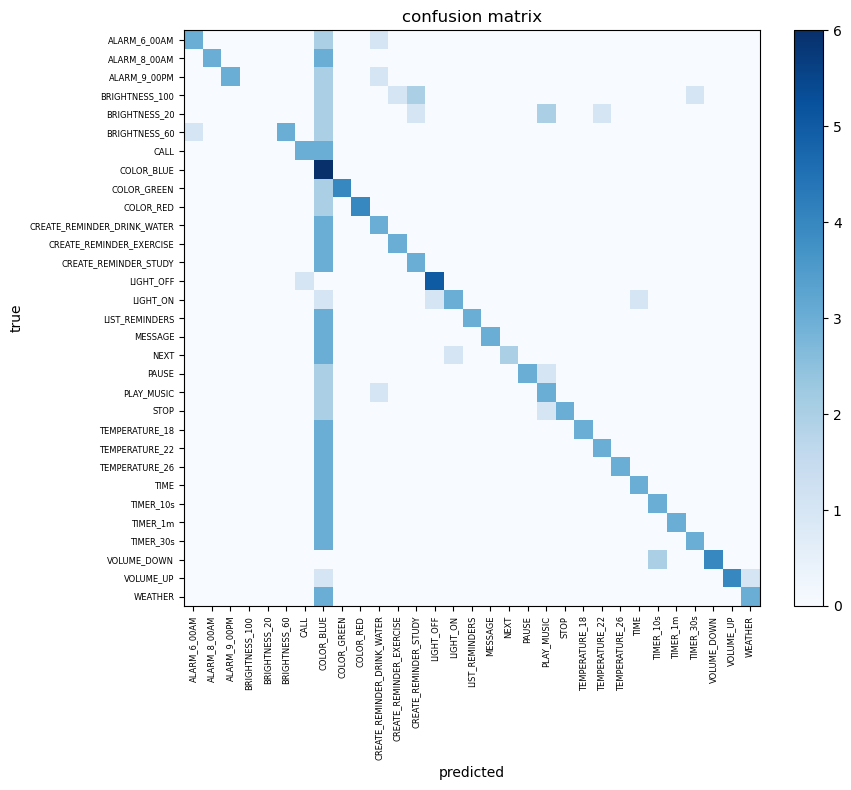

In [7]:
if ACC is not None and HAVE_MPL:
    cm = np.asarray(ACC["confusion"])
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(cm, cmap="Blues")
    k = len(CLASSES)
    ax.set_xticks(range(k))
    ax.set_xticklabels(CLASSES, rotation=90, fontsize=6)
    ax.set_yticks(range(k))
    ax.set_yticklabels(CLASSES, fontsize=6)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title("confusion matrix")
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout()
    p = RESULTS_DIR / "keyword_confusion_matrix.png"
    plt.savefig(p, dpi=120)
    plt.show()
elif ACC is not None:
    print("(install matplotlib to plot the labelled confusion matrix)")

## 5. False accept rate (FAR)

**FAR** = fraction of non-command / background clips that the classifier
**accepts as a command** (top-1 confidence ≥ the `UNKNOWN` threshold) instead of
rejecting them. **FRR** = fraction of real commands wrongly rejected.

A **threshold sweep** shows the trade-off: raising the threshold lowers FAR but
raises FRR (and can drop true-command accuracy).

In [8]:
FAR = None
if NEG_PROBS is not None and len(NEG_PROBS):
    neg_conf = NEG_PROBS.max(1)
    neg_pred = NEG_PROBS.argmax(1)
    accepted = neg_conf >= THR
    far = float(accepted.mean())

    pos_conf = POS_PROBS.max(1) if (POS_PROBS is not None and len(POS_PROBS)) else None
    pos_pred = POS_PROBS.argmax(1) if POS_PROBS is not None else None
    frr = float((pos_conf < THR).mean()) if pos_conf is not None else None

    fa_targets = Counter(CLASSES[i] for i in neg_pred[accepted])

    rows = []
    for thr in sorted({0.05, 0.1, round(THR, 3), 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9}):
        far_t = float((neg_conf >= thr).mean())
        if pos_conf is not None:
            rej = pos_conf < thr
            cov = float((~rej).mean())
            frr_t = float(rej.mean())
            acc_c = float((pos_pred[~rej] == POS_Y[~rej]).mean()) if (~rej).any() else float("nan")
        else:
            cov = frr_t = acc_c = float("nan")
        rows.append([float(thr), far_t, frr_t, cov, acc_c])

    FAR = {"n_negatives": int(len(NEG_PROBS)), "source": NEG_DESC, "threshold": THR,
           "far": far, "frr": frr, "accepted_as_command": int(accepted.sum()),
           "false_accept_targets": dict(fa_targets), "sweep": rows}

    print(f"negatives        : {FAR['n_negatives']}  ({NEG_DESC})")
    print(f"threshold        : {THR:.3f}")
    print(f"FAR              : {far*100:.2f}%  ({FAR['accepted_as_command']}/{FAR['n_negatives']} accepted as a command)")
    if frr is not None:
        print(f"FRR (real cmds)  : {frr*100:.2f}%")
    if fa_targets:
        print(f"false accepts -> : {dict(fa_targets)}")
    print(f"\n{'thr':>6s} {'FAR':>8s} {'FRR':>8s} {'coverage':>10s} {'acc@cov':>9s}")
    for thr, far_t, frr_t, cov, acc_c in rows:
        cov_s = f"{cov*100:9.2f}%" if cov == cov else "      n/a"
        acc_s = f"{acc_c*100:8.2f}%" if acc_c == acc_c else "     n/a"
        print(f"{thr:6.3f} {far_t*100:7.2f}% {frr_t*100:7.2f}% {cov_s} {acc_s}")
else:
    print("No negatives available -> FAR skipped (set SYNTHETIC_NEGATIVES=True).")

negatives        : 10  (manifest /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app/rpi_validation/test_data/holdout/manifest.csv)
threshold        : 0.163
FAR              : 100.00%  (10/10 accepted as a command)
FRR (real cmds)  : 40.32%
false accepts -> : {'PAUSE': 2, 'COLOR_BLUE': 1, 'CALL': 1, 'CREATE_REMINDER_STUDY': 2, 'PLAY_MUSIC': 3, 'LIGHT_OFF': 1}

   thr      FAR      FRR   coverage   acc@cov
 0.050  100.00%    0.00%    100.00%    51.08%
 0.100  100.00%    0.00%    100.00%    51.08%
 0.163  100.00%   40.32%     59.68%    82.88%
 0.200   80.00%   44.09%     55.91%    86.54%
 0.300   60.00%   49.46%     50.54%    93.62%
 0.400   40.00%   54.30%     45.70%    95.29%
 0.500   30.00%   56.45%     43.55%    96.30%
 0.600   30.00%   59.68%     40.32%    96.00%
 0.700    0.00%   62.90%     37.10%    95.65%
 0.800    0.00%   66.67%     33.33%    96.77%
 0.900    0.00%   76.34%     23.66%    97.73%


## 6. Latency & throughput

* **frontend** — NumPy log-mel extraction, **onnx** — pure `session.run`,
  **end-to-end** — `predict()` (what the app does per command).
* Real-time factor = end-to-end ÷ clip length; also a thread sweep.

In [9]:
def stats(t):
    t = np.asarray(t, float)
    return {"mean_ms": float(t.mean()), "median_ms": float(np.median(t)),
            "p95_ms": float(np.percentile(t, 95)), "p99_ms": float(np.percentile(t, 99)),
            "min_ms": float(t.min()), "max_ms": float(t.max()), "std_ms": float(t.std())}


def bench(fn, n_warm, n_runs):
    for i in range(n_warm):
        fn()
    ts = []
    for _ in range(n_runs):
        t = time.perf_counter_ns(); fn(); ts.append((time.perf_counter_ns() - t) / 1e6)
    return ts


BENCH_WAVS = ([load_wav(p) for p, _ in POS[:20]] if POS
              else [load_wav(p) for p in sorted((APP_DIR / "samples").glob("*.wav"))[:5]])
BENCH_WAVS = ([load_wav(p) for p, _ in POS[:20]] if POS
              else [load_wav(p) for p in sorted((APP_DIR / "samples").glob("*.wav"))[:5]])
BENCH_WAVS = BENCH_WAVS or [np.zeros(WIN, np.float32)]
MELS = [fe(w) for w in BENCH_WAVS]


class Cycler:
    def __init__(self, seq):
        self.seq = seq
        self.i = 0

    def __call__(self):
        v = self.seq[self.i % len(self.seq)]
        self.i += 1
        return v


next_wav, next_mel = Cycler(BENCH_WAVS), Cycler(MELS)
fe_t = bench(lambda: fe(next_wav()), N_WARMUP, N_RUNS)
onnx_t = bench(lambda: clf.sess.run(None, {clf.input_name: next_mel()}), N_WARMUP, N_RUNS)
e2e_t = bench(lambda: clf.predict(next_wav()), N_WARMUP, N_RUNS)

F, O, E = stats(fe_t), stats(onnx_t), stats(e2e_t)
RTF = E["mean_ms"] / (CLIP_S * 1000)
LATENCY = {"frontend": F, "onnx": O, "end_to_end": E, "real_time_factor": RTF,
           "throughput_per_s": 1000.0 / E["mean_ms"],
           "clip_ms": CLIP_S * 1000, "runs": N_RUNS}

print(f"clip length        : {CLIP_S*1000:.1f} ms   warmup={N_WARMUP} runs={N_RUNS}")
print(f"frontend   mean/p95: {F['mean_ms']:.2f} / {F['p95_ms']:.2f} ms")
print(f"onnx       mean/p95: {O['mean_ms']:.2f} / {O['p95_ms']:.2f} ms")
print(f"end-to-end mean/p95: {E['mean_ms']:.2f} / {E['p95_ms']:.2f} ms "
      f"(median {E['median_ms']:.2f}, p99 {E['p99_ms']:.2f})")
print(f"real-time factor   : {RTF:.4f}  (x{1/RTF:.1f} faster than real time)")
print(f"throughput         : {LATENCY['throughput_per_s']:.1f} inferences/s")

sweep = {}
mx = os.cpu_count() or 1
for nt in sorted({t for t in THREAD_SWEEP if t <= mx} | {min(2, mx)}):
    c = CommandClassifier(MODEL_DIR, intents=CLASSES, num_threads=nt, unknown_threshold=THR)
    s = stats(bench(lambda: c.predict(next_wav()), max(3, N_WARMUP // 2), max(20, N_RUNS // 2)))
    s["throughput_per_s"] = 1000.0 / s["mean_ms"]
    sweep[int(nt)] = s
    print(f"threads={nt}: mean={s['mean_ms']:6.2f}  p95={s['p95_ms']:6.2f}  "
          f"({s['throughput_per_s']:5.1f}/s)")
LATENCY["thread_sweep"] = sweep

clip length        : 1522.0 ms   warmup=10 runs=100
frontend   mean/p95: 3.43 / 4.05 ms
onnx       mean/p95: 169.94 / 229.48 ms
end-to-end mean/p95: 182.49 / 277.95 ms (median 159.77, p99 300.19)
real-time factor   : 0.1199  (x8.3 faster than real time)
throughput         : 5.5 inferences/s
threads=1: mean=288.62  p95=303.48  (  3.5/s)
threads=2: mean=170.35  p95=221.36  (  5.9/s)
threads=4: mean=179.15  p95=290.68  (  5.6/s)


## 7. Runtime stability & thermal drift

Back-to-back inference for `SUSTAINED_SECONDS`, sampling CPU temperature each
second. A rising second-half latency indicates throttling — the main risk for an
always-on Pi 5 workload.

sustained         : 133 inferences in 30s
latency mean/p95  : 225.52 / 338.90 ms
drift (1st->2nd)  : +53.61 ms (+27.0%)
cpu temp start/end: 66.7 / 63.9 C   max 67.2 C


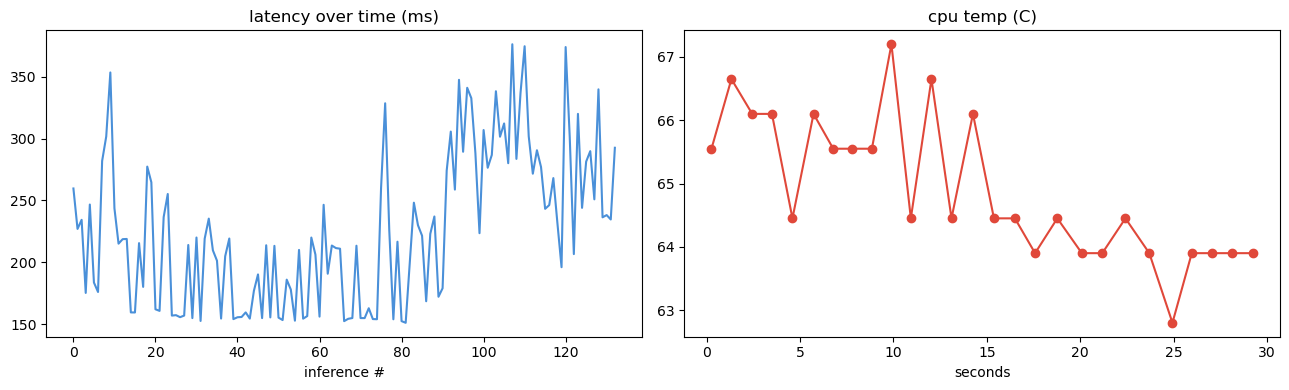

In [10]:
def sustained(seconds, temp_every=1.0):
    t_end = time.time() + seconds
    lat, temps, stamps = [], [], []
    next_temp = time.time()
    t0 = cpu_temp_c()
    while time.time() < t_end:
        w = next_wav()
        t = time.perf_counter_ns(); clf.predict(w)
        lat.append((time.perf_counter_ns() - t) / 1e6)
        now = time.time()
        if now >= next_temp:
            tv = cpu_temp_c()
            if tv is not None:
                temps.append(tv); stamps.append(now - t_end + seconds)
            next_temp = now + temp_every
    return np.asarray(lat), temps, stamps, t0, cpu_temp_c()


lat_s, temps, stamps, tc0, tc1 = sustained(SUSTAINED_SECONDS)
half = max(1, len(lat_s) // 2)
first, second = float(lat_s[:half].mean()), float(lat_s[half:].mean())
RUNTIME = {"seconds": SUSTAINED_SECONDS, "n": int(len(lat_s)),
           "mean_ms": float(lat_s.mean()), "p95_ms": float(np.percentile(lat_s, 95)),
           "first_half_ms": first, "second_half_ms": second,
           "drift_ms": second - first,
           "drift_pct": (second / first - 1) * 100 if first else 0.0,
           "temp_start_c": tc0, "temp_end_c": tc1,
           "temp_max_c": (max(temps) if temps else None)}
print(f"sustained         : {RUNTIME['n']} inferences in {SUSTAINED_SECONDS}s")
print(f"latency mean/p95  : {RUNTIME['mean_ms']:.2f} / {RUNTIME['p95_ms']:.2f} ms")
print(f"drift (1st->2nd)  : {RUNTIME['drift_ms']:+.2f} ms ({RUNTIME['drift_pct']:+.1f}%)")
print(f"cpu temp start/end: " + (f"{tc0:.1f} / {tc1:.1f} C   max {RUNTIME['temp_max_c']:.1f} C"
      if tc0 is not None else "n/a (not a Raspberry Pi)"))

if HAVE_MPL:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].plot(lat_s, color="#4a90d9"); ax[0].set_title("latency over time (ms)")
    ax[0].set_xlabel("inference #")
    if stamps:
        ax[1].plot(stamps, temps, "-o", color="#e0483a")
    ax[1].set_title("cpu temp (C)"); ax[1].set_xlabel("seconds")
    plt.tight_layout()
    p = RESULTS_DIR / "runtime_plots.png"; plt.savefig(p, dpi=120); plt.show()

## 8. Summary & report

In [11]:
SUMMARY = {"environment": ENV, "model": {"dir": str(MODEL_DIR), "classes": NUM_CLASSES,
           "unknown_threshold": clf.unknown_threshold, "load_ms": LOAD_MS,
           "window_samples": WIN, "clip_ms": CLIP_S * 1000},
           "dataset": {"positives": len(POS), "pos_source": POS_SRC,
                       "negatives": len(NEG_WAVS), "neg_source": NEG_DESC},
           "keyword_intent_accuracy": ACC, "false_accept_rate": FAR,
           "latency": LATENCY, "runtime": RUNTIME,
           "generated_at": time.strftime("%Y-%m-%d %H:%M:%S")}

report = RESULTS_DIR / "keyword_intent_validation_mex2_31class.json"
with open(report, "w") as f:
    json.dump(SUMMARY, f, indent=2, default=float)
if HAVE_PANDAS and ACC:
    pd.DataFrame(ACC["per_intent"]).T.to_csv(RESULTS_DIR / "per_intent_metrics.csv")

print("========================= KEYWORD INTENT VALIDATION =========================")
print(f"target              : {ENV.get('rpi_model') or ENV['platform']}")
print(f"model               : {NUM_CLASSES} intents, UNKNOWN thr={clf.unknown_threshold}")
print("-" * 76)
if ACC:
    print(f"KEYWORD INTENT ACC  : top-1 {ACC['top1']*100:.2f}% | top-3 {ACC['top3']*100:.2f}% "
          f"| top-5 {ACC['top5']*100:.2f}% | macro-F1 {ACC['macro_f1']*100:.2f}%  (n={ACC['n']})")
else:
    print("KEYWORD INTENT ACC  : n/a (no labeled clips)")
if FAR:
    print(f"FALSE ACCEPT RATE   : {FAR['far']*100:.2f}%  (n={FAR['n_negatives']}, {FAR['source']})")
    if FAR["frr"] is not None:
        print(f"FALSE REJECT RATE   : {FAR['frr']*100:.2f}%")
else:
    print("FALSE ACCEPT RATE   : n/a (no negatives)")
print(f"LATENCY (end-to-end): {LATENCY['end_to_end']['mean_ms']:.2f} ms "
      f"(p95 {LATENCY['end_to_end']['p95_ms']:.2f} ms) | RTF {LATENCY['real_time_factor']:.4f} "
      f"| {LATENCY['throughput_per_s']:.1f}/s")
print(f"RUNTIME (sustained) : {RUNTIME['n']} inf in {SUSTAINED_SECONDS}s | drift "
      f"{RUNTIME['drift_ms']:+.2f} ms ({RUNTIME['drift_pct']:+.1f}%)"
      + (f" | max temp {RUNTIME['temp_max_c']:.1f} C" if RUNTIME['temp_max_c'] is not None else ""))
print("-" * 76)
print(f"report              : {report}")
print("============================================================================")

========================= KEYWORD INTENT VALIDATION =========================
target              : Raspberry Pi 5 Model B Rev 1.1
model               : 31 intents, UNKNOWN thr=0.163
----------------------------------------------------------------------------
KEYWORD INTENT ACC  : top-1 51.08% | top-3 55.91% | top-5 60.75% | macro-F1 58.56%  (n=186)
FALSE ACCEPT RATE   : 100.00%  (n=10, manifest /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app/rpi_validation/test_data/holdout/manifest.csv)
FALSE REJECT RATE   : 40.32%
LATENCY (end-to-end): 182.49 ms (p95 277.95 ms) | RTF 0.1199 | 5.5/s
RUNTIME (sustained) : 133 inf in 30s | drift +53.61 ms (+27.0%) | max temp 67.2 C
----------------------------------------------------------------------------
report              : /home/sonny-rpi5/Documents/GitHub/AI231-MEX2/app/rpi_validation/results/keyword_intent_validation_mex2_31class.json


---

### Notes
* **FAR needs negatives.** Drop real non-command / background recordings into
  `test_data/_negative/*.wav` (folder name must be in the negative set) for a
  meaningful number. Otherwise synthetic non-speech negatives are used (a smoke
  test only — it will over-estimate how well real speech is rejected).
* **Accuracy needs positives** in `test_data/<CLASS>/*.wav` (CLASS = one of the
  31 intents) or a `manifest.csv` with `path,label`.
* Tune the operating point with the **threshold sweep**: pick the `UNKNOWN`
  threshold that balances FAR vs accuracy-on-covered, then set
  `command.unknown_threshold` in `config.yaml`.
* Run top-to-bottom; run once to warm up before trusting latency, and stop other
  CPU-heavy processes on the Pi.